# Mini-demo algorytmu ACO dla TSP

- Notebook służy tylko jako prosty test integracyjny modułu `ACO_alg.py`.
---

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from ACO_alg import ant_colony_optimization

## 1. Przykładowa macierz odległości

Na potrzeby testu używamy losowej instancji TSP z 12 miastami. <br>
Element `dist_matrix[i, j]` oznacza odległość między miastem `i` oraz miastem `j`. <br>
Na przekątnej są zera, ponieważ odległość miasta od samego siebie wynosi 0. <br>

In [14]:
rng = np.random.default_rng(42)

n_cities = 12
cities = rng.uniform(0, 100, size=(n_cities, 2))

diff = cities[:, np.newaxis, :] - cities[np.newaxis, :, :]
dist_matrix = np.sqrt(np.sum(diff ** 2, axis=2))

dist_matrix

array([[  0.        ,  27.19946951,  86.6136888 ,  34.74223423,
         64.5944927 ,  63.29057413,  40.53269552,  39.24911268,
         43.45050539,  20.01185774,   8.58320609,  49.50190085],
       [ 27.19946951,   0.        ,  81.34889544,  13.17768328,
         77.11079349,  53.90470326,  24.86638821,  62.7215344 ,
         70.27165623,   7.26354353,  35.72715704,  22.55786039],
       [ 86.6136888 ,  81.34889544,   0.        ,  69.33765461,
         52.63316082,  28.09021902,  57.05462753,  82.58598159,
        102.14516838,  81.00997378,  90.91412027,  88.0394769 ],
       [ 34.74223423,  13.17768328,  69.33765461,   0.        ,
         71.65207399,  41.49256653,  12.28821386,  64.28339818,
         75.12028574,  16.8108437 ,  43.15491292,  23.53207436],
       [ 64.5944927 ,  77.11079349,  52.63316082,  71.65207399,
          0.        ,  53.4633252 ,  63.61314647,  38.62759727,
         57.55979423,  72.26248462,  63.72256349,  95.18208339],
       [ 63.29057413,  53.90470326,

## 2. Uruchomienie algorytmu ACO

Uruchamiamy algorytm na małej instancji testowej.

Parametry:

- `n_ants` — liczba mrówek w jednej iteracji,
- `n_iterations` — liczba iteracji algorytmu,
- `alpha` — wpływ feromonów,
- `beta` — wpływ heurystyki, czyli bliskości miast,
- `rho` — współczynnik parowania feromonów,
- `q` — ilość feromonu zostawianego przez mrówki,
- `seed` — ziarno losowości, dzięki któremu wynik jest powtarzalny.


In [15]:
best_tour, best_length, history = ant_colony_optimization(
    dist_matrix=dist_matrix,
    n_ants=30,
    n_iterations=100,
    alpha=1.0,
    beta=3.0,
    rho=0.5,
    q=100.0,
    seed=42,
    start_city=0
)

print("Najlepsza trasa:", best_tour)
print("Długość najlepszej trasy:", best_length)
print("Liczba zapisanych wartości w historii:", len(history))

Najlepsza trasa: [0, 10, 9, 1, 11, 3, 6, 5, 2, 4, 7, 8]
Długość najlepszej trasy: 314.5846896195135
Liczba zapisanych wartości w historii: 100


## 3. Interpretacja wyniku

Trasa jest reprezentowana jako lista indeksów miast, na przykład:

```python
[0, 1, 3, 2]
```

Ostatni powrót do miasta startowego nie jest dopisywany do listy, ale jest uwzględniany przy liczeniu długości trasy.

In [16]:
print("Trasa jako cykl:")

cycle = best_tour + [best_tour[0]]
print(" -> ".join(map(str, cycle)))

Trasa jako cykl:
0 -> 10 -> 9 -> 1 -> 11 -> 3 -> 6 -> 5 -> 2 -> 4 -> 7 -> 8 -> 0


## 4. Historia zbieżności

Lista `history` przechowuje najlepszą znalezioną długość trasy po każdej iteracji.

In [17]:
history

[np.float64(326.3483502914504),
 np.float64(326.3483502914504),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.float64(314.5846896195135),
 np.floa

## 6. Prosty wykres zbieżności

Na wykresie pokazujemy, jak zmieniała się najlepsza znaleziona długość trasy w kolejnych iteracjach.

Dla małej instancji wynik może ustabilizować się bardzo szybko, ponieważ przestrzeń możliwych tras jest niewielka.

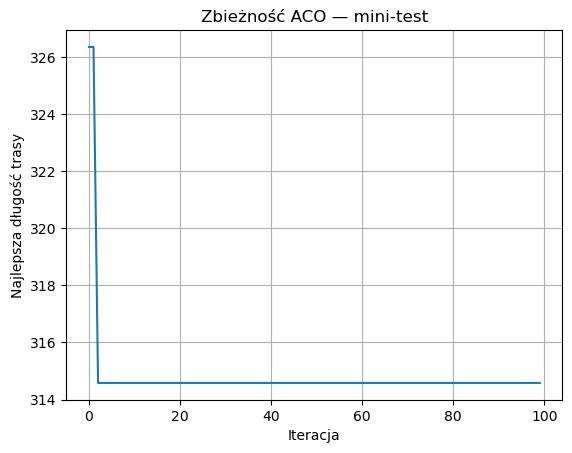

In [18]:
plt.plot(history)
plt.xlabel("Iteracja")
plt.ylabel("Najlepsza długość trasy")
plt.title("Zbieżność ACO — mini-test")
plt.grid(True)
plt.show()